## Dataset 1:
Traditional Phishing Indicators

Focus: Classic web security features
Features: IP addresses, URL length, SSL state, redirects
Target: Binary classification (-1: legitimate, 1: phishing)
Balance: Slightly imbalanced (0.796 ratio)

In [48]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("datasets/dataset1.csv")

In [10]:
df.head()

,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [12]:
df.shape

(11055, 32)

In [14]:
df.columns

Index(['index ', 'having_IPhaving_IP_Address ', 'URLURL_Length ',
       'Shortining_Service ', 'having_At_Symbol ', 'double_slash_redirecting ',
       'Prefix_Suffix ', 'having_Sub_Domain ', 'SSLfinal_State ',
       'Domain_registeration_length ', 'Favicon ', 'port ', 'HTTPS_token ',
       'Request_URL ', 'URL_of_Anchor ', 'Links_in_tags ', 'SFH ',
       'Submitting_to_email ', 'Abnormal_URL ', 'Redirect ', 'on_mouseover ',
       'RightClick ', 'popUpWidnow ', 'Iframe ', 'age_of_domain ',
       'DNSRecord ', 'web_traffic ', 'Page_Rank ', 'Google_Index ',
       'Links_pointing_to_page ', 'Statistical_report ', 'Result'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   index                         11055 non-null  int64
 1   having_IPhaving_IP_Address    11055 non-null  int64
 2   URLURL_Length                 11055 non-null  int64
 3   Shortining_Service            11055 non-null  int64
 4   having_At_Symbol              11055 non-null  int64
 5   double_slash_redirecting      11055 non-null  int64
 6   Prefix_Suffix                 11055 non-null  int64
 7   having_Sub_Domain             11055 non-null  int64
 8   SSLfinal_State                11055 non-null  int64
 9   Domain_registeration_length   11055 non-null  int64
 10  Favicon                       11055 non-null  int64
 11  port                          11055 non-null  int64
 12  HTTPS_token                   11055 non-null  int64
 13  Request_URL                   1

In [20]:
df.isnull().sum()

index                           0
having_IPhaving_IP_Address      0
URLURL_Length                   0
Shortining_Service              0
having_At_Symbol                0
double_slash_redirecting        0
Prefix_Suffix                   0
having_Sub_Domain               0
SSLfinal_State                  0
Domain_registeration_length     0
Favicon                         0
port                            0
HTTPS_token                     0
Request_URL                     0
URL_of_Anchor                   0
Links_in_tags                   0
SFH                             0
Submitting_to_email             0
Abnormal_URL                    0
Redirect                        0
on_mouseover                    0
RightClick                      0
popUpWidnow                     0
Iframe                          0
age_of_domain                   0
DNSRecord                       0
web_traffic                     0
Page_Rank                       0
Google_Index                    0
Links_pointing

In [24]:
df.dtypes

index                           int64
having_IPhaving_IP_Address      int64
URLURL_Length                   int64
Shortining_Service              int64
having_At_Symbol                int64
double_slash_redirecting        int64
Prefix_Suffix                   int64
having_Sub_Domain               int64
SSLfinal_State                  int64
Domain_registeration_length     int64
Favicon                         int64
port                            int64
HTTPS_token                     int64
Request_URL                     int64
URL_of_Anchor                   int64
Links_in_tags                   int64
SFH                             int64
Submitting_to_email             int64
Abnormal_URL                    int64
Redirect                        int64
on_mouseover                    int64
RightClick                      int64
popUpWidnow                     int64
Iframe                          int64
age_of_domain                   int64
DNSRecord                       int64
web_traffic 

In [26]:
df.nunique()

index                           11055
having_IPhaving_IP_Address          2
URLURL_Length                       3
Shortining_Service                  2
having_At_Symbol                    2
double_slash_redirecting            2
Prefix_Suffix                       2
having_Sub_Domain                   3
SSLfinal_State                      3
Domain_registeration_length         2
Favicon                             2
port                                2
HTTPS_token                         2
Request_URL                         2
URL_of_Anchor                       3
Links_in_tags                       3
SFH                                 3
Submitting_to_email                 2
Abnormal_URL                        2
Redirect                            2
on_mouseover                        2
RightClick                          2
popUpWidnow                         2
Iframe                              2
age_of_domain                       2
DNSRecord                           2
web_traffic 

In [32]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].describe()

,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,5528.000000,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,...,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584,0.113885
std,3191.447947,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,...,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437,0.993539
min,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2764.500000,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,5528.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,8291.500000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,11055.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [36]:
target_col = 'Result'

In [38]:
print("\nLabel distribution:\n", df[target_col].value_counts(normalize=True))



Label distribution:
 Result
 1    0.556943
-1    0.443057
Name: proportion, dtype: float64


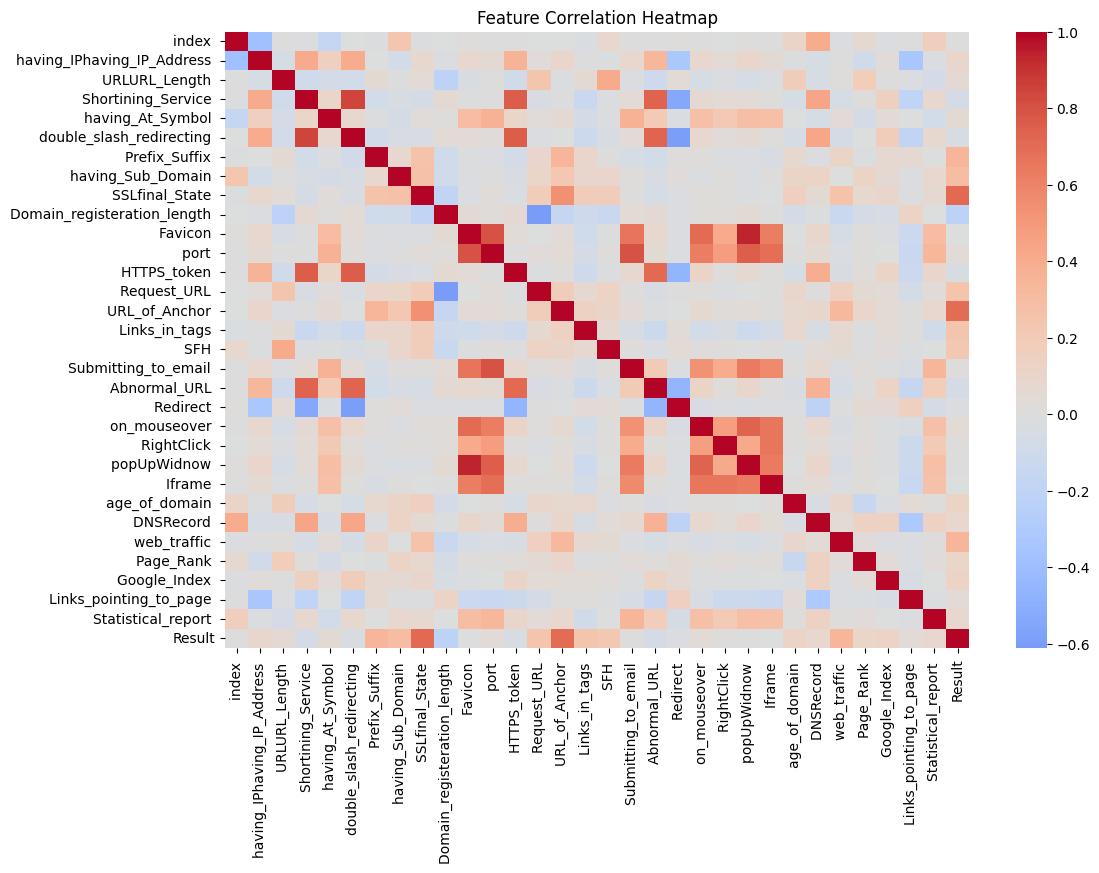

In [50]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

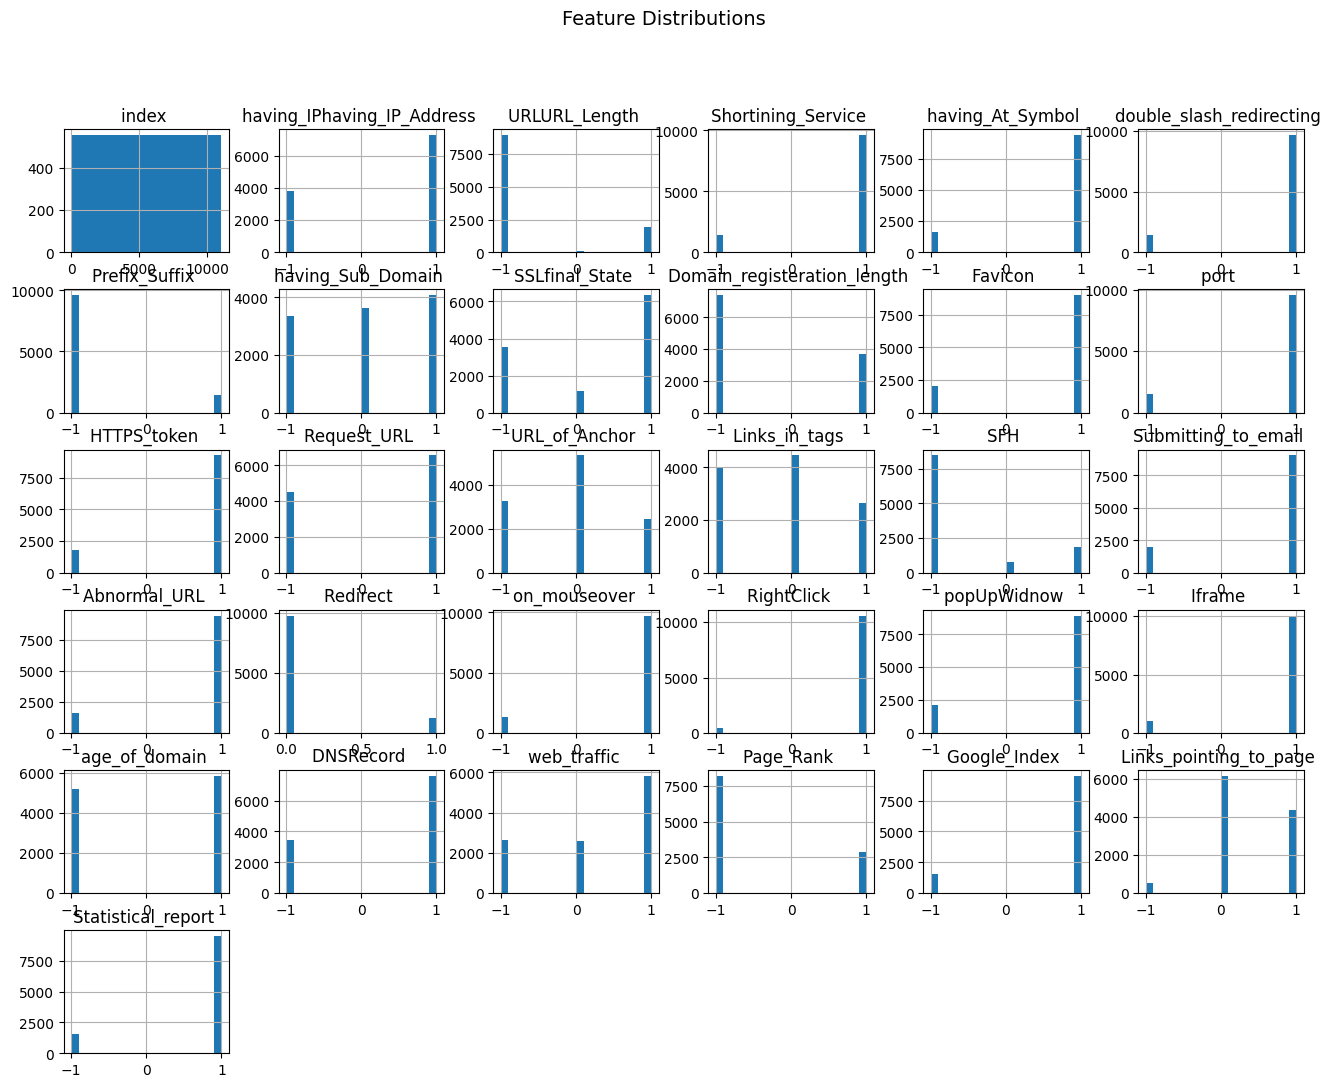

In [52]:
num_cols = [c for c in df.columns if c != target_col]
df[num_cols].hist(bins=20, figsize=(16,12))
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()

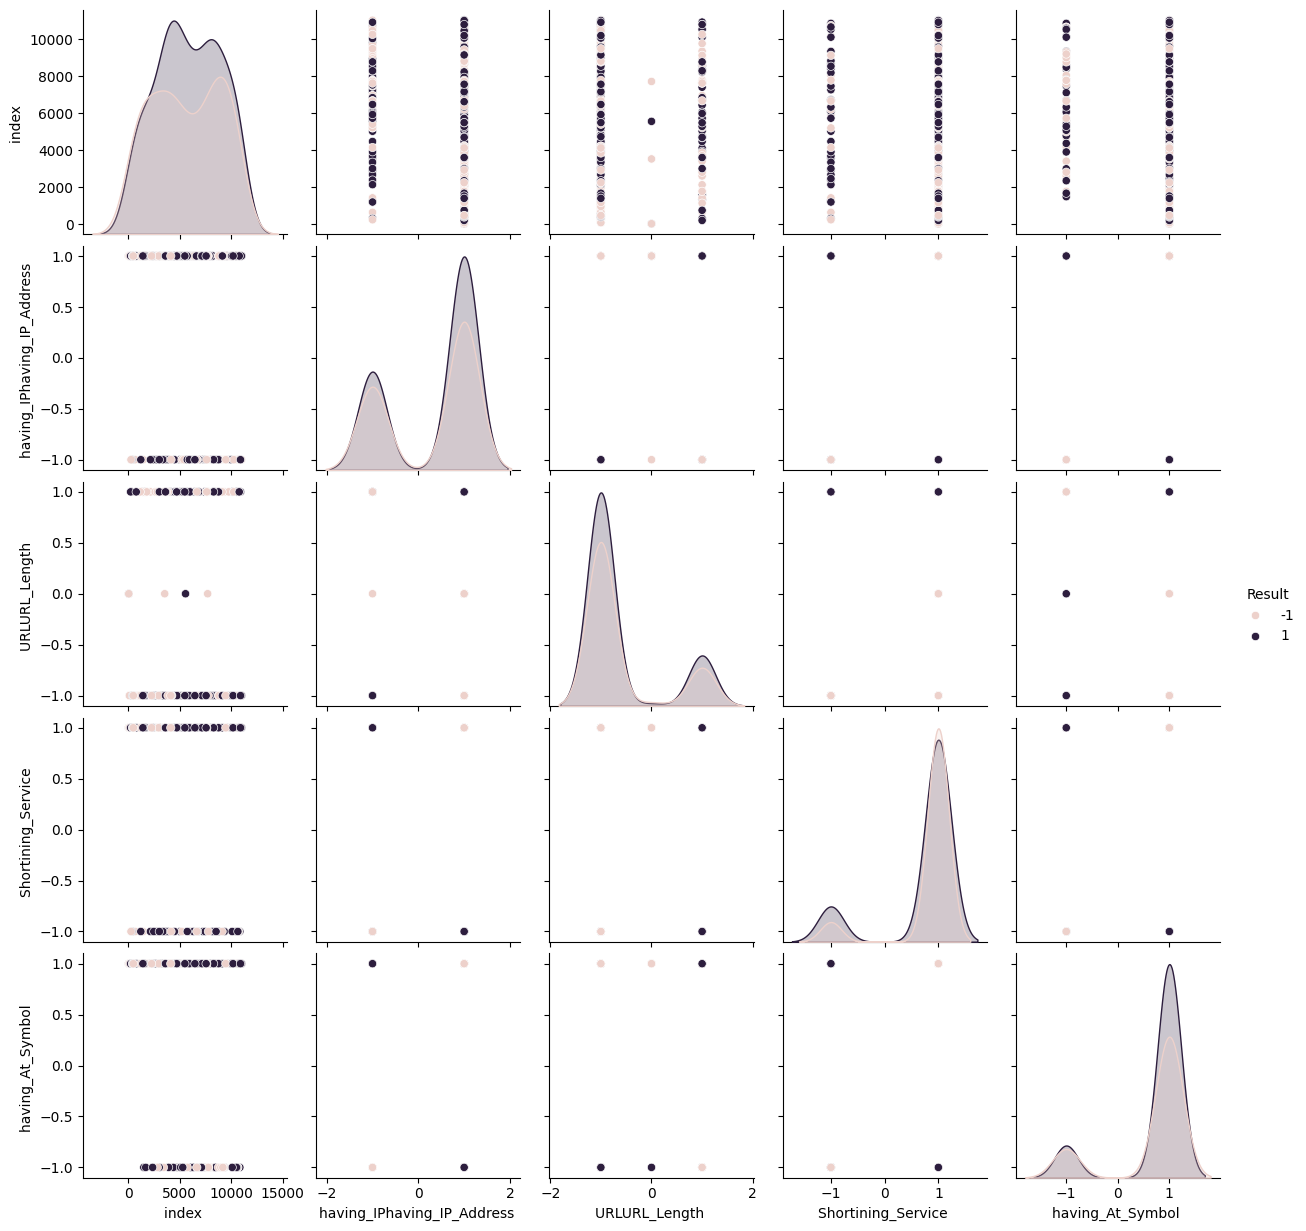

In [54]:
sample_df = df.sample(400, random_state=42)
sns.pairplot(sample_df[[*num_cols[:5], target_col]], hue=target_col, diag_kind='kde')
plt.show()

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [60]:
# Separate features and Target
X = df.drop(columns=['Result'])
y = df['Result']

In [62]:
# Train Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [64]:
# Scale Numeric Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (8844, 31)
Test shape: (2211, 31)


In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [68]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42)
}

In [72]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    print(f"\n{name} Accuracy: {acc:4f}")
    print(classification_report(y_test, preds))


LogisticRegression Accuracy: 0.928087
              precision    recall  f1-score   support

          -1       0.93      0.90      0.92       980
           1       0.92      0.95      0.94      1231

    accuracy                           0.93      2211
   macro avg       0.93      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211


DecisionTree Accuracy: 0.957033
              precision    recall  f1-score   support

          -1       0.96      0.94      0.95       980
           1       0.96      0.97      0.96      1231

    accuracy                           0.96      2211
   macro avg       0.96      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211


RandomForest Accuracy: 0.966531
              precision    recall  f1-score   support

          -1       0.97      0.96      0.96       980
           1       0.97      0.97      0.97      1231

    accuracy                           0.97      2211
   macro avg       0.97

In [74]:
from sklearn.model_selection import GridSearchCV

In [76]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [78]:
rf = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf, param_grid, cv=3, n_jobs=-1, verbose=1)
grid.fit(X_train_scaled, y_train)

print("Best params: ", grid.best_params_)
print("Best CV Accuracy: ", grid.best_score_)
best_rf = grid.best_estimator_

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best params:  {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Accuracy:  0.966644052464948


In [80]:
from sklearn.metrics import accuracy_score, classification_report
preds = best_rf.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Test Accuracy: 0.9674355495251018
              precision    recall  f1-score   support

          -1       0.97      0.96      0.96       980
           1       0.97      0.98      0.97      1231

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



## Hyperparameter Tuning (GridSearchCV)

### Goal: 
Improve model performance by finding the optimal settings (hyperparameters) rather than relying on defaults.

Used GridSearchCV to test multiple combinations of:
n_estimators: number of trees in the forest
max_depth: maximum depth of each tree (controls overfitting)
min_samples_split: minimum samples needed to split an internal node
min_samples_leaf: minimum samples required at each leaf node

### How it works:
Grid search trains the model several times using cross-validation — splitting the training data into smaller folds — and checks which hyperparameter set performs best on average.

### Why it matters:
It reduces the chance of overfitting and ensures the model generalizes well on unseen data.

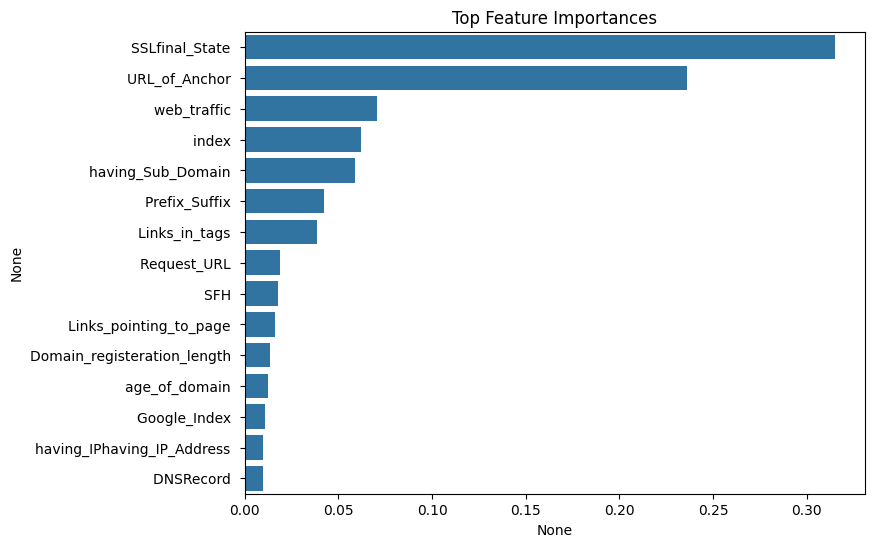

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = pd.Series(best_rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=top_features, y=top_features.index)
plt.title("Top Feature Importances")
plt.show()

## Feature Importance Analysis

### Goal: 
Understand which features influence predictions the most.

### What we did:

Used the trained Random Forest’s attribute feature_importances_ to rank features by their contribution to the model’s decisions.

### How it helps:

Identifies which website or URL characteristics are strong phishing indicators (e.g., presence of “@”, SSL state, domain age).
Can guide feature engineering (e.g., drop weak features, enhance strong ones).
Improves explainability when presenting results to stakeholders.

In [92]:
# Fix labels for boosting models
y_train_bin = y_train.replace({-1: 0, 1: 1}).astype(int)
y_test_bin  = y_test.replace({-1: 0, 1: 1}).astype(int)

In [94]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_scaled, y_train_bin)
xgb_preds = xgb.predict(X_test_scaled)
xgb_proba = xgb.predict_proba(X_test_scaled)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_test_bin, xgb_preds))
print("ROC AUC:", roc_auc_score(y_test_bin, xgb_proba))
print(classification_report(y_test_bin, xgb_preds))

XGBoost Accuracy: 0.968340117593849
ROC AUC: 0.9966826373116264
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       980
           1       0.97      0.97      0.97      1231

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



## Boosted Model Comparison (XGBoost)

### Goal: 
Compare Random Forest with a boosting algorithm to see if we can outperform it.

#### Difference from Random Forest:
Random Forest builds trees independently and averages their results.
XGBoost (Extreme Gradient Boosting) builds trees sequentially, where each new tree tries to correct errors made by previous ones.

#### Advantages of XGBoost:
Generally higher accuracy on structured/tabular data.
Handles bias–variance tradeoff better via learning rate and boosting mechanism.
Built-in regularization and missing-value handling.

#### When to prefer XGBoost:
If you need top performance and can tolerate longer training times.
If you’re fine tuning many parameters and have enough compute.

In [101]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.0/559.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 1.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 MB 3.3 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]5/6 [shap]]te]


In [103]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/Users/aple/Documents/Data Science/Automobile Project/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [105]:
X_train_sdf = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_sdf  = pd.DataFrame(X_test_scaled,  columns=X.columns)

In [107]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_sdf)   # use test set for explanation

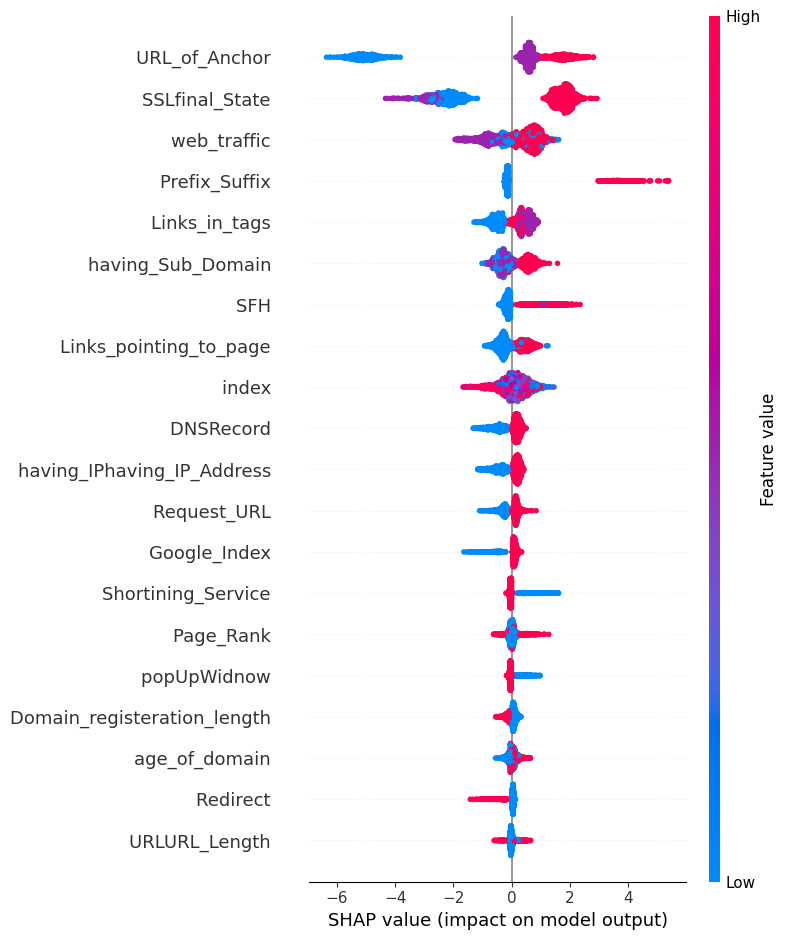

In [109]:
shap.summary_plot(shap_values, X_test_sdf, show=True)

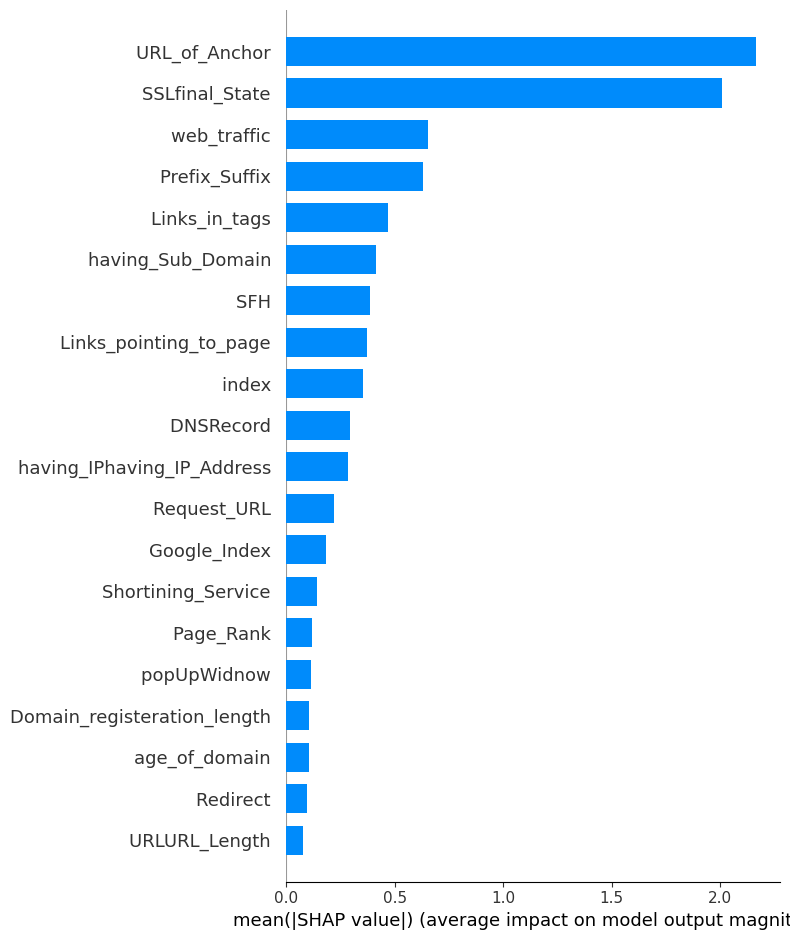

In [111]:
shap.summary_plot(shap_values, X_test_sdf, plot_type="bar", show=True)

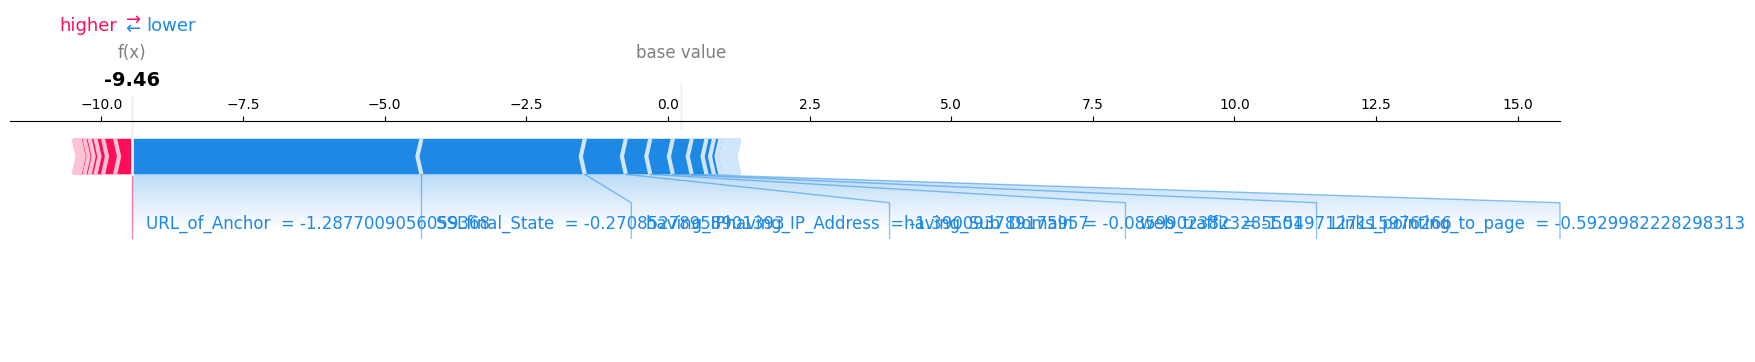

In [113]:
i = 0  # pick a row index from test set
shap.force_plot(explainer.expected_value, shap_values[i], X_test_sdf.iloc[i,:], matplotlib=True)

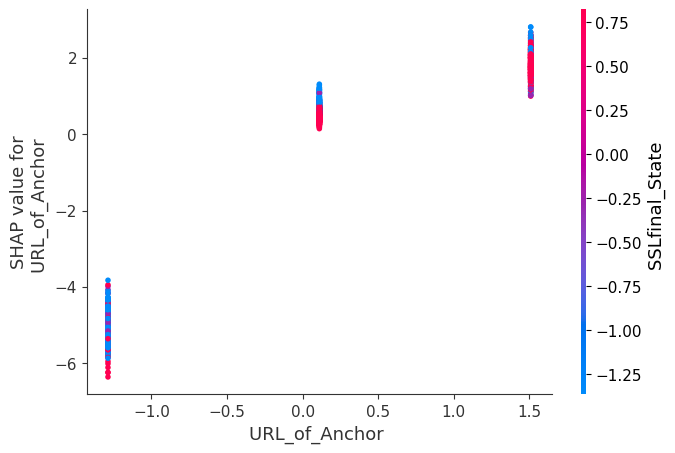

In [115]:
top_feature = X_test_sdf.columns[np.argsort(np.abs(shap_values).mean(0))[::-1][0]]
shap.dependence_plot(top_feature, shap_values, X_test_sdf, show=True)

### Summary dot: 
features at top matter most; color shows feature value (high/low), x-axis is push toward phishing (→) or legitimate (←).
### Bar: 
average absolute importance (good for ranking).
### Force plot: 
why this one URL was flagged.
### Dependence: 
how changing one feature shifts prediction; watch for non-linearities.

In [118]:
import joblib
artifacts = {
    "model": xgb,                 # fitted XGBClassifier
    "scaler": scaler,             # fitted StandardScaler
    "features": list(X.columns),  # feature order
    "threshold": 0.5              # change later if you tune it
}
joblib.dump(artifacts, "phish_xgb_v1.joblib")

['phish_xgb_v1.joblib']